# 篇末综合 同一观测下的后验与预测比较

## 学习目标与先修知识

在相同信息与预算下比较局部近似、采样（sampling）、变分和独立预测，解释模型（model）错误。

先修：9.1—9.5的后验（posterior）、采样、变分、EM与预测检验。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

一条计算链可以同时含有模型假设、后验近似和有限计算误差。总预测偏差很小时，如何确认不是几种错误偶然抵消？本综合先把可核验目标拆开，再判断一个共同失配能否靠增加预算解决。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

同一Gamma后验的众数与均值并不相同。先用形状3、率2的后验算出它们，再比较局部方差（variance）与精确方差。

In [2]:
a,b=3.,2.
print("众数、均值、精确方差、局部方差：",(a-1)/b,a/b,a/b**2,(a-1)/b**2)

众数、均值、精确方差、局部方差： 1.0 1.5 0.75 0.5


## 模型假设

清除事件（event）的简化计数模型使用正参数（parameter）k和公开Gamma先验（prior）；暴露E已按参考尺度数值化，似然（likelihood）为Poisson(kE)。它是可解参照，不等同于带高斯测量误差的连续总量模型。第二个可解参照是相关二维高斯后验。所有真值只在核验阶段使用；后验好坏和生理机制是否成立分别判断。

## 数学解释与推导

先验$k\sim\operatorname{Gamma}(a,b)$，计数$c\mid k\sim\operatorname{Poisson}(kE)$，合并关于k的项得到$k\mid c\sim\operatorname{Gamma}(a+c,b+E)$。其均值$(a+c)/(b+E)$与方差$(a+c)/(b+E)^2$给出积分参照；内部众数要求$a+c>1$。

若已得到精确相关高斯$N(0,\Sigma)$，$\Sigma=\begin{pmatrix}1&\rho\\\rho&1\end{pmatrix}$，独立高斯因子的最优均值为0、方差为$1-\rho^2$。即使把坐标更新做到极限（limit），相对熵（relative entropy）仍有$-\tfrac12\log(1-\rho^2)$的正差距；不能把优化残差（residual）小解释为后验精确。

最后考虑可解的偏差模型$\theta\sim N(0,4)$、$y_i\mid\theta\sim N(\theta,1)$。训练读数$[1,2,3]$给出$v=1/(1/4+3)$、$m=v\sum y_i$，未来预测方差$v+1$。用点估计代替参数积分会漏掉v；若实际未来噪声增大，而计算模型仍固定为1，连精确后验预测（posterior predictive inference）也会失配。误差的来源需借助这些可解参照逐层定位。

本篇的四类问题因此各有检查对象：归一化和单位；转移核与有限链；目标函数与近似族；独立预测及模型范围。把计算结果与各自的检查对象对应起来，就能定位误差来源。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def gamma_local(shape,rate,count,exposure):
    a,b=shape+count,rate+exposure
    if a<=1:return None,None,None,'boundary'
    mode=(a-1)/b;curvature=(a-1)/mode**2
    return mode,curvature,1/curvature,'interior'


def logsumexp(values):
    top=max(values)
    return top+math.log(sum(math.exp(x-top) for x in values))


def grid_posterior(nodes,log_values):
    # Trapezoidal integration: endpoint nodes receive half interval weights.
    widths=[(nodes[1]-nodes[0])/2]+[(nodes[i+1]-nodes[i-1])/2 for i in range(1,len(nodes)-1)]+[(nodes[-1]-nodes[-2])/2]
    log_mass=[l+math.log(w) for l,w in zip(log_values,widths)]
    normalizer=logsumexp(log_mass)
    weights=[math.exp(l-normalizer) for l in log_mass]
    mean=sum(w*x for w,x in zip(weights,nodes))
    variance=sum(w*(x-mean)**2 for w,x in zip(weights,nodes))
    return weights,mean,variance,normalizer


def mean_field_sweep(precision,target_mean,current_mean):
    result=list(current_mean)
    for i in range(2):
        j=1-i
        result[i]=target_mean[i]-precision[i][j]*(result[j]-target_mean[j])/precision[i][i]
    variances=[1/precision[i][i] for i in range(2)]
    determinant=precision[0][0]*precision[1][1]-precision[0][1]*precision[1][0]
    delta=[a-b for a,b in zip(result,target_mean)]
    quadratic=sum(delta[i]*precision[i][j]*delta[j] for i in range(2) for j in range(2))
    kl=.5*(sum(precision[i][i]*variances[i] for i in range(2))+quadratic-2-math.log(determinant*variances[0]*variances[1]))
    return result,variances,kl


def normal_update(prior_mean,prior_variance,observations,noise_variance):
    precision=1/prior_variance+len(observations)/noise_variance
    variance=1/precision
    mean=variance*(prior_mean/prior_variance+sum(observations)/noise_variance)
    return mean,variance,variance+noise_variance


def predictive_moments(weights,conditional_means,conditional_variances):
    total=sum(weights);w=[x/total for x in weights]
    mean=sum(p*m for p,m in zip(w,conditional_means))
    within=sum(p*v for p,v in zip(w,conditional_variances))
    between=sum(p*(m-mean)**2 for p,m in zip(w,conditional_means))
    return mean,within+between,within,between


def normal_logpdf(value,mean,variance):
    return -.5*(math.log(2*math.pi*variance)+(value-mean)**2/variance)

## 对照实验

在同一张图中保留两个不同来源的误差：Gamma局部高斯的偏斜损失，以及相关高斯均值场（mean-field approximation）的非零KL极限。数值和图形都保留各自模型身份。

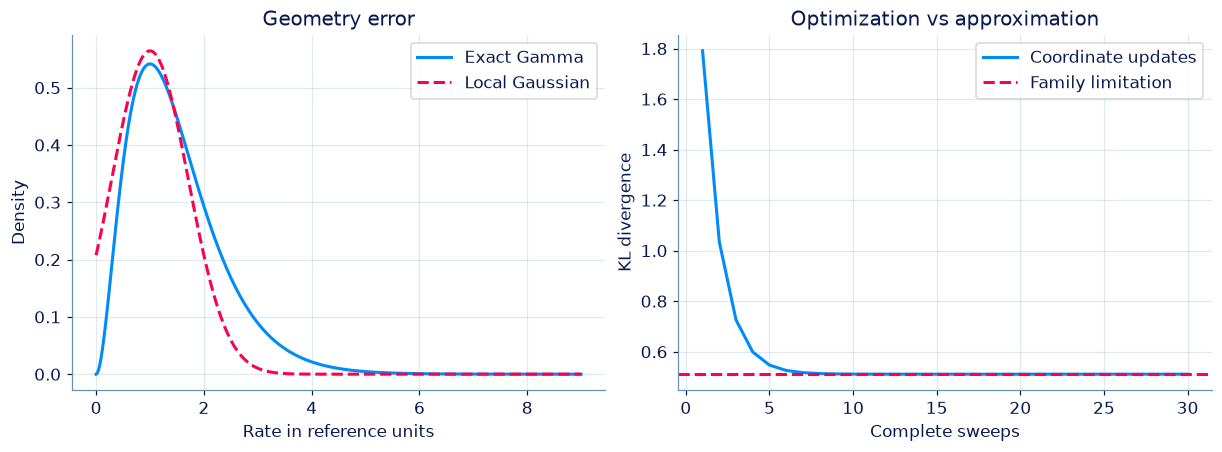

| 参照 | 均值 | 方差 |
| --- | --- | --- |
| Gamma精确 | 1.5 | 0.75 |
| Gamma局部高斯 | 1 | 0.5 |
| 未来读数 | 1.84615 | 1.30769 |
| 仅代入参数 | 1.84615 | 1 |

In [4]:
prior_shape,prior_rate,count,exposure=1.,1.,2,1.
a,b=prior_shape+count,prior_rate+exposure
mode,curvature,local_var,_=gamma_local(prior_shape,prior_rate,count,exposure)
k=np.linspace(.0001,9,3000);exact=np.exp(a*math.log(b)-math.lgamma(a)+(a-1)*np.log(k)-b*k)
local=np.exp([normal_logpdf(z,mode,local_var) for z in k]);rho=.8;P=(np.array([[1.,-rho],[-rho,1.]])/(1-rho*rho)).tolist();current=[2.,-2.];history=[]
for _ in range(30):
    current,diagonal,gap=mean_field_sweep(P,[0.,0.],current);history.append(gap)
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].plot(k,exact,label='Exact Gamma');axes[0].plot(k,local,'--',label='Local Gaussian');axes[0].set(xlabel='Rate in reference units',ylabel='Density',title='Geometry error');axes[0].legend()
axes[1].plot(np.arange(1,31),history,label='Coordinate updates');axes[1].axhline(-.5*math.log(1-rho*rho),color=PINK,ls='--',label='Family limitation');axes[1].set(xlabel='Complete sweeps',ylabel='KL divergence',title='Optimization vs approximation');axes[1].legend();plt.show()
m,v,pv=normal_update(0,4,[1,2,3],1)
display(Markdown(show_table(['参照','均值','方差'],[('Gamma精确',a/b,a/b**2),('Gamma局部高斯',mode,local_var),('未来读数',m,pv),('仅代入参数',m,1.)])))

## 结果解释

图左说明众数位置和局部曲率不能完整表示偏斜后验；图右说明充分优化仍受近似族限制。表中的预测方差差异来自是否积分参数，不是随机采样误差。解答下面的八题时，先明确对象、条件和接口，再计算；无需依赖前一题的作答结果。随机步骤使用题目给出的候选点与均匀数。

### 独立核对

用Gamma函数矩比独立核对后验积分；用矩阵（matrix）形式KL核对均值场极限；用原点二阶矩复核预测方差分解。

In [5]:
nodes=np.linspace(.00001,20,20001);_,gm,gv,_=grid_posterior(nodes,[(a-1)*math.log(z)-b*z for z in nodes])
analytic_mean=math.exp(math.lgamma(a+1)-math.lgamma(a))/b
analytic_second=math.exp(math.lgamma(a+2)-math.lgamma(a))/b**2
np.testing.assert_allclose([gm,gv],[analytic_mean,analytic_second-analytic_mean**2],atol=1e-6)
Q=np.diag(diagonal);Sigma=np.linalg.inv(P);mu=np.array(current)
matrix_kl=.5*(np.trace(np.array(P)@Q)+mu@np.array(P)@mu-2+np.linalg.slogdet(Sigma)[1]-np.linalg.slogdet(Q)[1])
np.testing.assert_allclose(history[-1],matrix_kl,atol=1e-12)
assert abs(history[-1]+.5*math.log(1-rho*rho))<1e-8
result=predictive_moments([.5,.5],[m-math.sqrt(v),m+math.sqrt(v)],[1,1])
np.testing.assert_allclose(result[:2],[m,pv])
print('三种独立参照通过。综合练习的边界情况和信息使用仍须分别判断。')

三种独立参照通过。综合练习的边界情况和信息使用仍须分别判断。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 多项选择题：先明确预测对象

同一组清除观测（observation）用于建立正参数（parameter）k的后验（posterior）。哪些安排正确？

- **A.** 说明先验（prior）来源并检查后验可积。
- **B.** 参数可信区间（credible interval）与未来读数区间分别计算。
- **C.** 重复使用同一似然（likelihood）作为新的独立实验。
- **D.** 只报告MAP就已经报告全部不确定性。

[作答：先明确预测对象](http://127.0.0.1:8000/parts/09-%E6%A6%82%E7%8E%87%E5%BB%BA%E6%A8%A1%E4%B8%8E%E8%BF%91%E4%BC%BC%E6%8E%A8%E6%96%AD/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p09-cap-prior)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：收敛声明需要哪些证据

两条短链各困在不同模态（mode），接受率都为80%。哪项结论可靠？

- **A.** 后验（posterior）均值已收敛。
- **B.** 接受率一致就可以直接合并当独立样本。
- **C.** 当前预算不足以支持充分混合，应报告模式覆盖并扩展检查。
- **D.** 删去均值较差的一条链。

[作答：收敛声明需要哪些证据](http://127.0.0.1:8000/parts/09-%E6%A6%82%E7%8E%87%E5%BB%BA%E6%A8%A1%E4%B8%8E%E8%BF%91%E4%BC%BC%E6%8E%A8%E6%96%AD/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p09-cap-diagnostic)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：后验局部近似与边界

独立事件（event）计数服从Poisson(kE)，正参数（parameter）k有Gamma(a,b)先验（prior），b采用率参数化。计算内点模态（mode）及局部曲率，并按规则处理边界情形。

**函数与代码模板**

```python
def solve(
    shape: float,
    rate: float,
    count: int,
    exposure: float,
) -> tuple[float | None, float | None, float | None, str]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `shape` | `float` | Gamma先验形状a。 | 1 |
| `rate` | `float` | Gamma先验率b，密度含exp(−bk)。 | T |
| `count` | `int` | Poisson事件总数c。 | 1 |
| `exposure` | `float` | 已知暴露时长E，事件均值为kE。 | T |

**返回值**

按以下顺序返回元组：(mode, curvature, variance, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mode` | <code>float &#124; None</code> | 内点模态；边界情形为None。 | 1/T |
| `curvature` | <code>float &#124; None</code> | 负对数后验（posterior）在模态处的二阶导数（derivative）。 | T² |
| `variance` | <code>float &#124; None</code> | 局部高斯方差（variance），即曲率的倒数。 | 1/T² |
| `status` | `str` | interior或boundary。 | 不适用 |

**计算规则**

更新a′=a+c，b′=b+E；a′>1时mode=(a′−1)/b′，curvature=(a′−1)/mode²，variance=1/curvature；a′≤1统一返回(None,None,None,"boundary")。

**约束与边界**

- a,b>0；0≤c≤100；E≥0；a,b,E≤100。 E=0时仅允许c=0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| shape | Gamma先验形状a。 | 2 | 1 |
| rate | Gamma先验率b，密度含exp(−bk)。 | 1 | T |
| count | Poisson事件总数c。 | 3 | 1 |
| exposure | 已知暴露时长E，事件均值为kE。 | 2 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
shape = 2.0
rate = 1.0
count = 3
exposure = 2.0

result = solve(shape, rate, count, exposure)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mode | 内点模态；边界情形为None。 | ≈ 1.333333 | 1/T |
| curvature | 负对数后验（posterior）在模态处的二阶导数（derivative）。 | 2.25 | T² |
| variance | 局部高斯方差（variance），即曲率的倒数。 | ≈ 0.4444444 | 1/T² |
| status | interior或boundary。 | interior | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.3333333333333333,
                   2.25,
                   0.4444444444444444,
                   'interior')
```

**样例解释**

后验形状5、率3；众数4/3，曲率9/4，局部方差4/9。精确方差5/9与局部方差不同，不能混用。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：后验局部近似与边界](http://127.0.0.1:8000/parts/09-%E6%A6%82%E7%8E%87%E5%BB%BA%E6%A8%A1%E4%B8%8E%E8%BF%91%E4%BC%BC%E6%8E%A8%E6%96%AD/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p09-cap-local)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：固定提议下的接受与拒绝

目标是等权双高斯混合。用题给候选点、提议比与均匀数重放MH链；不得再随机抽样。

**函数与代码模板**

```python
def solve(
    initial: float,
    candidates: list[float],
    log_reverse_over_forward: list[float],
    uniforms: list[float],
    separation: float,
) -> tuple[list[float], list[bool]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `float` | 初始链状态（state）。 | 1 |
| `candidates` | `list[float]` | 依次给定的候选点，拒绝后下一候选仍按本列表读取。 | 1 |
| `log_reverse_over_forward` | `list[float]` | 每一步log q(当前&#124;候选)−log q(候选&#124;当前)。 | 1 |
| `uniforms` | `list[float]` | 固定均匀数；0≤u<1。 | 1 |
| `separation` | `float` | 等权N(−d,1)、N(d,1)目标中的d。 | 1 |

**返回值**

按以下顺序返回元组：(states, accepted)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 含初值（initial condition）和每次接受/拒绝后状态。 | 1 |
| `accepted` | `list[bool]` | 按步骤返回是否接受。 | 不适用 |

**计算规则**

logα=min(0,logp(candidate)−logp(current)+log_reverse_over_forward[i])。u=0或logu<logα即接受，否则保持当前值。d=0退化成N(0,1)。

**约束与边界**

- 三组步骤列表等长0—100；数值绝对值≤100；0≤d≤5；均匀数在[0,1)。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 初始链状态（state）。 | 0 | 1 |
| candidates | 依次给定的候选点，拒绝后下一候选仍按本列表读取。 | [1.0, -1.0, 2.0] | 1 |
| log_reverse_over_forward | 每一步log q(当前|候选)−log q(候选|当前)。 | [0.6931471805599453, -2.3025850929940455, 0.0] | 1 |
| uniforms | 固定均匀数；0≤u<1。 | [0.8, 0.2, 0.1] | 1 |
| separation | 等权N(−d,1)、N(d,1)目标中的d。 | 0 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 0.0
candidates = [1.0, -1.0, 2.0]
log_reverse_over_forward = [0.6931471805599453,
                            -2.3025850929940455,
                            0.0]
uniforms = [0.8, 0.2, 0.1]
separation = 0.0

result = solve(initial, candidates, log_reverse_over_forward, uniforms, separation)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 含初值（initial condition）和每次接受/拒绝后状态。 | [0.0, 1.0, 1.0, 2.0] | 1 |
| accepted | 按步骤返回是否接受。 | [True, False, True] | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 1.0, 1.0, 2.0],
                   [True, False, True])
```

**样例解释**

第一步接受概率（probability）为1；第二步目标密度不变但反向/正向提议比为.1，因此拒绝；第三步概率exp(−1.5)大于.1，接受。状态为[0,1,1,2]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：固定提议下的接受与拒绝](http://127.0.0.1:8000/parts/09-%E6%A6%82%E7%8E%87%E5%BB%BA%E6%A8%A1%E4%B8%8E%E8%BF%91%E4%BC%BC%E6%8E%A8%E6%96%AD/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p09-cap-mh)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：均值场更新与证据差距

目标p=N(μ,P⁻¹)，近似q=q1q2。实现一轮精确坐标更新并计算解析KL。

**函数与代码模板**

```python
def solve(
    precision: list[list[float]],
    target_mean: list[float],
    current_mean: list[float],
) -> tuple[list[float], list[float], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `precision` | `list[list[float]]` | 二维高斯目标的对称正定（positive definite）精度矩阵（matrix）P。 | 1 |
| `target_mean` | `list[float]` | 目标均值μ。 | 1 |
| `current_mean` | `list[float]` | 当前两个因子均值。 | 1 |

**返回值**

按以下顺序返回元组：(means, variances, kl)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[float]` | 先更新第一因子、再用新值更新第二因子的均值。 | 1 |
| `variances` | `list[float]` | 独立因子的方差（variance）1/Pii。 | 1 |
| `kl` | `float` | 更新后的KL(q&#124;&#124;p)，单位nat。 | nat |

**计算规则**

m1=μ1−P12(m2−μ2)/P11；再用新m1更新m2=μ2−P21(m1−μ1)/P22。vi=1/Pii；KL=[tr(Pdiag(v))+(m−μ)ᵀP(m−μ)−2−log(det(P)v1v2)]/2。

**约束与边界**

- 二维正定P，特征值（eigenvalue）在[0.05,20]，均值绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| precision | 二维高斯目标的对称正定（positive definite）精度矩阵（matrix）P。 | [[2.0, -1.0], [-1.0, 2.0]] | 1 |
| target_mean | 目标均值μ。 | [1.0, -1.0] | 1 |
| current_mean | 当前两个因子均值。 | [3.0, 1.0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
precision = [[2.0, -1.0], [-1.0, 2.0]]
target_mean = [1.0, -1.0]
current_mean = [3.0, 1.0]

result = solve(precision, target_mean, current_mean)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 先更新第一因子、再用新值更新第二因子的均值。 | [2.0, -0.5] | 1 |
| variances | 独立因子的方差（variance）1/Pii。 | [0.5, 0.5] | 1 |
| kl | 更新后的KL(q||p)，单位nat。 | ≈ 0.893841 | nat |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([2.0, -0.5],
                   [0.5, 0.5],
                   0.8938410362258904)
```

**样例解释**

先更新第一均值到2，再用新值更新第二均值到−.5；两个方差均为.5。更新后的均值仍未到目标均值，KL同时包含优化误差和独立因子限制。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：均值场更新与证据差距](http://127.0.0.1:8000/parts/09-%E6%A6%82%E7%8E%87%E5%BB%BA%E6%A8%A1%E4%B8%8E%E8%BF%91%E4%BC%BC%E6%8E%A8%E6%96%AD/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p09-cap-variational)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：同一留出条件下的评分与预算

用同一个高斯混合预测分布（distribution）评分若干独立观测（observation），保留区间覆盖与计算预算。评分使用完整混合密度，不改成匹配矩的单高斯。

**函数与代码模板**

```python
def solve(
    observed: list[float],
    weights: list[float],
    means: list[float],
    variances: list[float],
    lower: list[float],
    upper: list[float],
    evaluations: int,
) -> tuple[float | None, float | None, float | None, int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `observed` | `list[float]` | 独立最终评估读数。 | U |
| `weights` | `list[float]` | 预测高斯混合的非负权重，和为正。 | 1 |
| `means` | `list[float]` | 各预测高斯分量均值。 | U |
| `variances` | `list[float]` | 各预测高斯分量方差（variance）。 | U² |
| `lower` | `list[float]` | 与读数一一对应的预先确定区间下界。 | U |
| `upper` | `list[float]` | 对应上界，边界点算覆盖。 | U |
| `evaluations` | `int` | 形成预测所用的密度评估次数，原样报告。 | 次 |

**返回值**

按以下顺序返回元组：(mse, mean_log_score, coverage, budget)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mse` | <code>float &#124; None</code> | 读数相对混合均值的平均平方误差。 | U² |
| `mean_log_score` | <code>float &#124; None</code> | 均值log预测密度，越大越好；同一U尺度下比较。 | 1 |
| `coverage` | <code>float &#124; None</code> | 落在各自闭区间内的比例。 | 1 |
| `budget` | `int` | 原样返回evaluations。 | 次 |

**计算规则**

m=sum(wi mi)/sum(w)；MSE=mean((y−m)²)；logscore=mean(log sum(normalized wi·Normal(y|mi,vi)))；coverage=mean(lo≤y≤hi)。无观测时前三项None，预算仍返回。

**约束与边界**

- 0—100观测；1—10分量；vi∈[.01,100]；数值绝对值≤100；区间与观测等长，lo≤hi；evaluations≥0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| observed | 独立最终评估读数。 | [-1.0, 1.0, 3.0] | U |
| weights | 预测高斯混合的非负权重，和为正。 | [1.0, 1.0] | 1 |
| means | 各预测高斯分量均值。 | [-1.0, 1.0] | U |
| variances | 各预测高斯分量方差（variance）。 | [0.25, 0.25] | U² |
| lower | 与读数一一对应的预先确定区间下界。 | [-2.0, -2.0, -2.0] | U |
| upper | 对应上界，边界点算覆盖。 | [2.0, 2.0, 2.0] | U |
| evaluations | 形成预测所用的密度评估次数，原样报告。 | 500 | 次 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
observed = [-1.0, 1.0, 3.0]
weights = [1.0, 1.0]
means = [-1.0, 1.0]
variances = [0.25, 0.25]
lower = [-2.0, -2.0, -2.0]
upper = [2.0, 2.0, 2.0]
evaluations = 500

result = solve(observed, weights, means, variances, lower, upper, evaluations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mse | 读数相对混合均值的平均平方误差。 | ≈ 3.666667 | U² |
| mean_log_score | 均值log预测密度，越大越好；同一U尺度下比较。 | ≈ -3.585382 | 1 |
| coverage | 落在各自闭区间内的比例。 | ≈ 0.6666667 | 1 |
| budget | 原样返回evaluations。 | 500 | 次 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (3.6666666666666665,
                   -3.5853815956101585,
                   0.6666666666666666,
                   500)
```

**样例解释**

混合均值为0，所以MSE=(1+1+9)/3=11/3；3个读数中2个被覆盖，覆盖率2/3。log分数必须在每个读数处先相加两分量密度再取log；预算保持500。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：同一留出条件下的评分与预算](http://127.0.0.1:8000/parts/09-%E6%A6%82%E7%8E%87%E5%BB%BA%E6%A8%A1%E4%B8%8E%E8%BF%91%E4%BC%BC%E6%8E%A8%E6%96%AD/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p09-cap-predictive)

### 第 7 题 · 迁移挑战 · 10 分 · 多项选择题：似然变大是否代表机制成立

混合模型（model）尝试多个初值（initial condition），其中一组通过缩小分量方差（variance）得到极大似然（likelihood）。哪些判断成立？

- **A.** 需检查方差塌缩，而不直接宣布更好的生理机制。
- **B.** 交换标签可能产生相同密度，不是新的机制证据。
- **C.** EM单调上升必给全局有限最优。
- **D.** 独立预测与明确约束能提供补充检查。

[作答：似然变大是否代表机制成立](http://127.0.0.1:8000/parts/09-%E6%A6%82%E7%8E%87%E5%BB%BA%E6%A8%A1%E4%B8%8E%E8%BF%91%E4%BC%BC%E6%8E%A8%E6%96%AD/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p09-cap-em)

### 第 8 题 · 迁移挑战 · 10 分 · 多项选择题：新条件下的校准失败

同一训练模型（model）的网格、MCMC和VI预测在新输入（input）条件下都偏低，网格细化后仍如此。哪些后续步骤恰当？

- **A.** 保留原预测和失败案例。
- **B.** 考虑缺失输入机制或噪声假设，重新建模后用未参与更新的数据验证。
- **C.** 因网格近乎精确，所以真实机制一定正确。
- **D.** 把本次评估用于更新后，仍将拟合结果当独立验证。

[作答：新条件下的校准失败](http://127.0.0.1:8000/parts/09-%E6%A6%82%E7%8E%87%E5%BB%BA%E6%A8%A1%E4%B8%8E%E8%BF%91%E4%BC%BC%E6%8E%A8%E6%96%AD/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p09-cap-misspecification)

**进一步阅读**

[Murphy，Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html)：后验近似、采样与预测检验。

[Blei 等，Variational Inference，v9](https://arxiv.org/html/1601.00670v9)：第2节的下界与坐标更新；本节数值为独立设计的教学小例子。